# 05. Final Prediction and SHAP Interpretation (Mainline GB)

## Goal

This notebook closes the **main pipeline** of the project.

At this point, the main story is no longer about trying many interventions.
The main story is:

- compare candidate models
- benchmark them under stress
- keep a strong and defensible **Gradient Boosting** mainline model
- generate the final test prediction file
- interpret that final mainline model with SHAP

The more exploratory adaptive / missing-feature extension can remain as a **separate research extension notebook**.

## Notebook Roadmap

1. Load processed train/test data  
2. Refit the **mainline Gradient Boosting** model on the full processed training set  
3. Export the final test prediction file  
4. Build SHAP explanations for the same model  
5. Save the final SHAP figures and feature-importance table

This notebook is intentionally simple.
It is meant to keep the project ending clean, coherent, and easy to explain.

## Input Data and Project Paths

In [1]:
from pathlib import Path
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

for p in [PROJECT_ROOT, SRC_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_DIR = PROJECT_ROOT / "results" / "models"

for p in [TABLE_DIR, FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

from model import get_models
from shap_utils import build_shap_explainer, compute_shap_values, get_mean_abs_shap, get_top_features

sns.set_theme(style="whitegrid")

In [2]:
train_processed = pd.read_csv(DATA_DIR / "train_processed.csv")
test_processed = pd.read_csv(DATA_DIR / "test_processed.csv")

print("train_processed shape:", train_processed.shape)
print("test_processed shape:", test_processed.shape)

train_processed shape: (1451, 276)
test_processed shape: (1459, 275)


## 1. Prepare train / test matrices

The mainline prediction model uses the processed training data and the processed test matrix with the same feature columns.

In [3]:
X_train = train_processed.drop("SalePrice_log", axis=1).copy().astype(float)
y_train = train_processed["SalePrice_log"].copy().astype(float)

X_test = test_processed.copy().astype(float)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Missing values in X_train:", int(X_train.isnull().sum().sum()))
print("Missing values in X_test:", int(X_test.isnull().sum().sum()))

X_train shape: (1451, 275)
X_test shape: (1459, 275)
Missing values in X_train: 0
Missing values in X_test: 0


## 2. Refit the mainline Gradient Boosting model

In the final project structure, the mainline model is the plain **GradientBoostingRegressor** already supported by the earlier model-comparison and stress-benchmark stages.

So here I simply refit that model on the full processed training set, then use it for:

- final test prediction
- final SHAP interpretation

This keeps the end of the main pipeline straightforward and internally consistent.

In [4]:
models = get_models(random_state=42)
final_model = models["GradientBoosting"]
final_model.fit(X_train, y_train)

joblib.dump(final_model, MODEL_DIR / "final_mainline_gb.joblib")
print("[Saved]", MODEL_DIR / "final_mainline_gb.joblib")
print("Loaded final mainline model type:", type(final_model))

[Saved] /Users/rissa/Documents/housing-robust-ml/results/models/final_mainline_gb.joblib
Loaded final mainline model type: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


## 3. Final prediction export

This is the prediction-delivery step of the main pipeline.

In [5]:
y_test_pred_log = final_model.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)

submission = pd.DataFrame({
    "Id": range(1, len(y_test_pred) + 1),
    "SalePrice": y_test_pred
})

submission.head()

,Id,SalePrice
0,1,124322.533355
1,2,155055.064137
2,3,187308.032697
3,4,195673.519008
4,5,185318.125110


In [6]:
submission.to_csv(TABLE_DIR / "final_test_predictions_mainline_gb.csv", index=False)
submission.to_csv(TABLE_DIR / "final_test_predictions.csv", index=False)

print("[Saved]", TABLE_DIR / "final_test_predictions_mainline_gb.csv")
print("[Saved]", TABLE_DIR / "final_test_predictions.csv")

[Saved] /Users/rissa/Documents/housing-robust-ml/results/tables/final_test_predictions_mainline_gb.csv
[Saved] /Users/rissa/Documents/housing-robust-ml/results/tables/final_test_predictions.csv


## 4. SHAP setup

SHAP is now applied to the **same mainline GB model** used for the final prediction file.

This matters because the model submitted for prediction and the model interpreted with SHAP should be the same object.

In [7]:
X_background = X_train.sample(n=min(300, len(X_train)), random_state=42)
X_sample = X_train.sample(n=min(500, len(X_train)), random_state=42)

print("X_background shape:", X_background.shape)
print("X_sample shape:", X_sample.shape)

X_background shape: (300, 275)
X_sample shape: (500, 275)


In [8]:
explainer = build_shap_explainer(final_model, X_background)
shap_values = compute_shap_values(explainer, X_sample)

print("SHAP explainer built successfully.")
print("Underlying model used for SHAP:", type(final_model))

SHAP explainer built successfully.
Underlying model used for SHAP: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


## 5. Global SHAP importance

The bar plot answers:

> Which variables matter most overall for the mainline GB model?

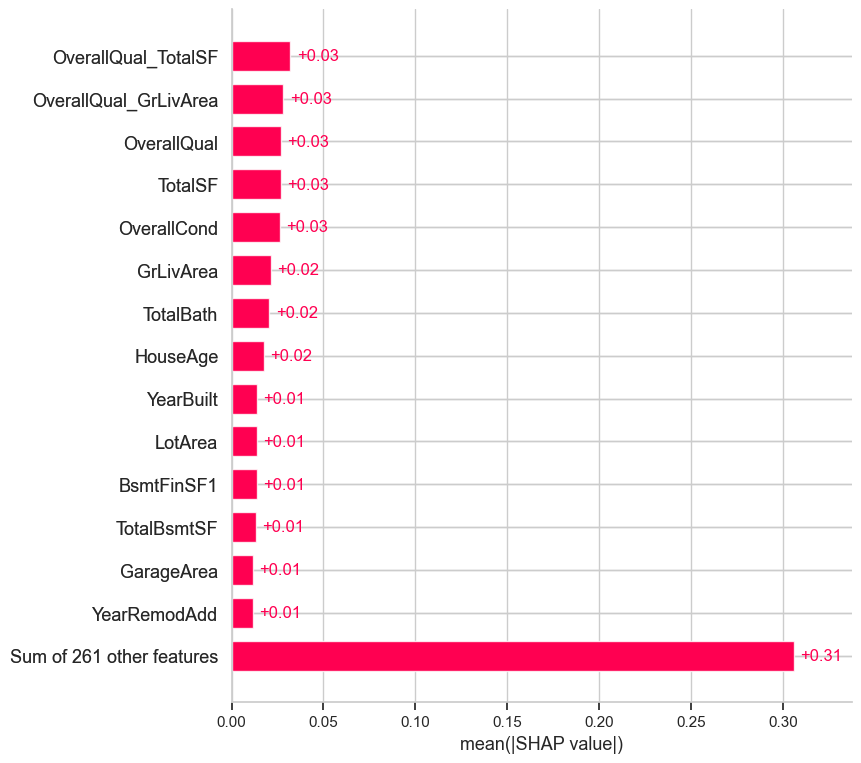

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_bar_importance.png


In [9]:
import shap

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.savefig(FIG_DIR / "final_shap_bar_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("[Saved]", FIG_DIR / "final_shap_bar_importance.png")

## 6. SHAP beeswarm plot

The beeswarm plot adds direction and spread:

- whether high feature values usually push the prediction up or down
- whether the effect is concentrated or highly variable

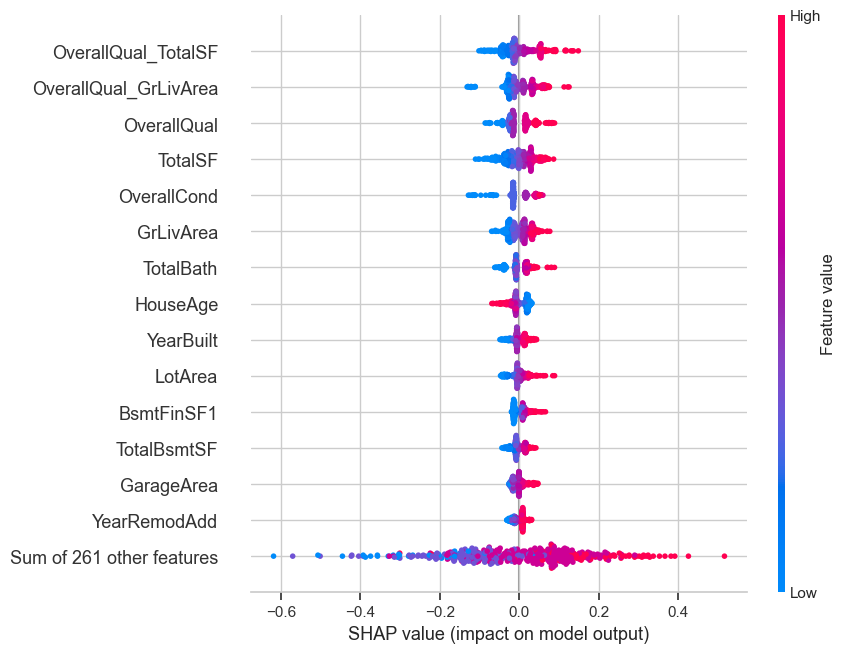

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_beeswarm.png


In [10]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.savefig(FIG_DIR / "final_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

print("[Saved]", FIG_DIR / "final_shap_beeswarm.png")

## 7. Save the SHAP importance table

This table becomes the bridge between visual interpretation and final writing / README discussion.

In [11]:
shap_importance_df = get_mean_abs_shap(shap_values)
shap_importance_df.head(20)

,feature,mean_abs_shap
0,OverallQual_TotalSF,0.031935
1,OverallQual_GrLivArea,0.028106
2,OverallQual,0.026846
3,TotalSF,0.026654
4,OverallCond,0.026124
5,GrLivArea,0.021328
6,TotalBath,0.020549
7,HouseAge,0.017616
8,YearBuilt,0.013708
9,LotArea,0.013607


In [12]:
shap_importance_df.head(20).to_csv(TABLE_DIR / "final_shap_importance.csv", index=False)
print("[Saved]", TABLE_DIR / "final_shap_importance.csv")

[Saved] /Users/rissa/Documents/housing-robust-ml/results/tables/final_shap_importance.csv


In [13]:
top_features = get_top_features(shap_importance_df, top_n=6)
top_features

['OverallQual_TotalSF',
 'OverallQual_GrLivArea',
 'OverallQual',
 'TotalSF',
 'OverallCond',
 'GrLivArea']

## 8. Dependence plots for top features

These plots answer:

> How does the prediction move as one important feature changes?

SHAP dependence plot for: OverallQual_TotalSF


<Figure size 640x480 with 0 Axes>

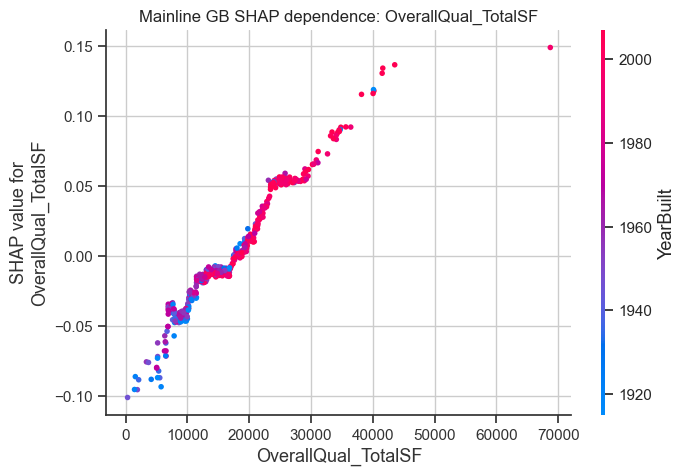

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_OverallQual_TotalSF.png
SHAP dependence plot for: OverallQual_GrLivArea


<Figure size 640x480 with 0 Axes>

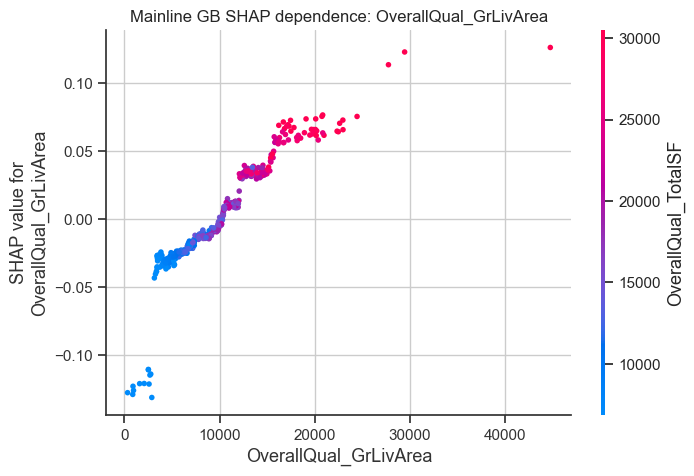

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_OverallQual_GrLivArea.png
SHAP dependence plot for: OverallQual


<Figure size 640x480 with 0 Axes>

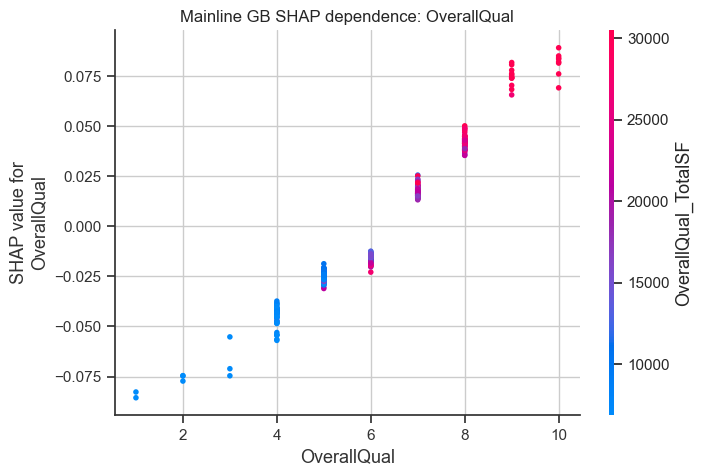

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_OverallQual.png
SHAP dependence plot for: TotalSF


<Figure size 640x480 with 0 Axes>

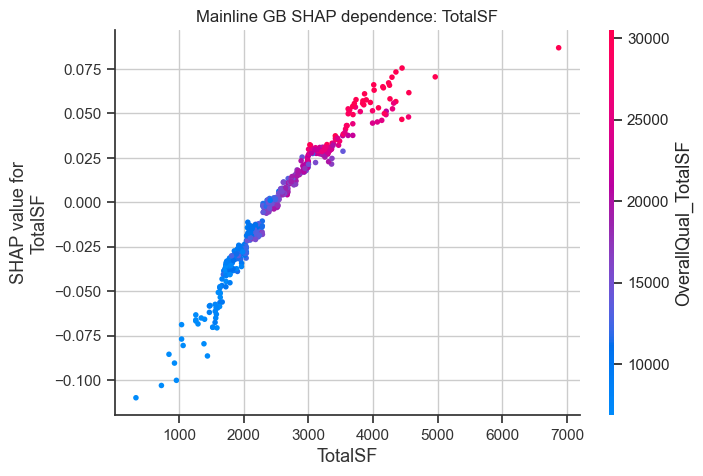

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_TotalSF.png
SHAP dependence plot for: OverallCond


<Figure size 640x480 with 0 Axes>

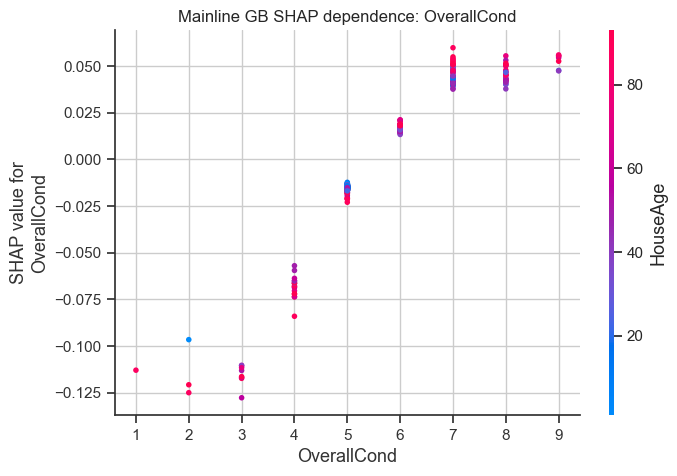

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_OverallCond.png
SHAP dependence plot for: GrLivArea


<Figure size 640x480 with 0 Axes>

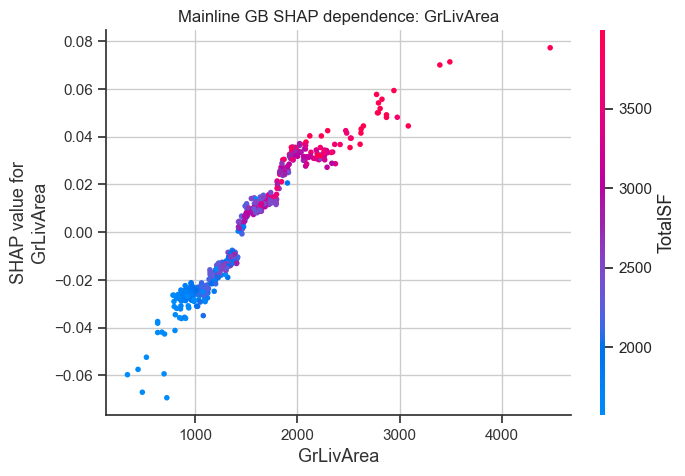

[Saved] /Users/rissa/Documents/housing-robust-ml/results/figures/final_shap_dependence_GrLivArea.png


In [14]:
for feature in top_features:
    print(f"SHAP dependence plot for: {feature}")
    plt.figure()
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_sample,
        interaction_index="auto",
        show=False
    )
    plt.title(f"Mainline GB SHAP dependence: {feature}")
    plt.savefig(
        FIG_DIR / f"final_shap_dependence_{feature}.png",
        dpi=180,
        bbox_inches="tight"
    )
    plt.show()
    print("[Saved]", FIG_DIR / f"final_shap_dependence_{feature}.png")

## Final interpretation note

This notebook is the clean ending of the **mainline project**:

- the final prediction file comes from a strong mainline GB model
- the SHAP interpretation explains the same mainline GB model
- the exploratory adaptive / missing-feature work can remain a separate extension, rather than being forced into the main pipeline

That separation makes the overall project easier to explain and more honest.